In [32]:
# Veri işleme için pandas ve numpy
import pandas as pd
import numpy as np

# Grafik çizmek için matplotlib
import matplotlib.pyplot as plt

# Veriyi eğitim-test olarak bölmek için
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Sayısal ve kategorik sütunlara farklı işlem uygulamak için
from sklearn.compose import ColumnTransformer

# İşlem adımlarını sıraya koymak için pipeline
from sklearn.pipeline import Pipeline

# Kategorik verileri sayısallaştırmak ve sayısal verileri ölçeklemek için
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Eksik değer doldurmak için
from sklearn.impute import SimpleImputer

# Baseline model
from sklearn.dummy import DummyRegressor
# XGBoost regresyon modeli
from xgboost import XGBRegressor

# Regresyon modelleri
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Performans metrikleri
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Özellik önemini görmek için
from sklearn.inspection import permutation_importance

In [33]:
# CSV dosyasını oku
# Kendi dosya yoluna göre güncelle
df = pd.read_csv(r"C:\Users\Ceren\Documents\ogrenci_analiz\student_productivity_distraction_dataset_20000.csv")

# İlk 5 satırı göster
print("İlk 5 satır:")
display(df.head())

# Veri boyutunu göster
print("Veri boyutu (satır, sütun):", df.shape)

İlk 5 satır:


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


Veri boyutu (satır, sütun): (20000, 18)


In [34]:
# Tüm sütun isimlerini göster
print("Sütunlar:")
print(df.columns.tolist())

print("\nVeri tipi ve eksik bilgi durumu:")
df.info()

Sütunlar:
['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']

Veri tipi ve eksik bilgi durumu:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  str    
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hour

In [35]:
# Her sütunda kaç eksik değer var?
print("Eksik değer sayıları:")
print(df.isnull().sum().sort_values(ascending=False))

# Aynı satırdan kaç tane var?
print("\nDuplicate (tekrarlı) satır sayısı:")
print(df.duplicated().sum())

Eksik değer sayıları:
student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

Duplicate (tekrarlı) satır sayısı:
0


In [36]:
# Sayısal sütunları seç
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Kategorik sütunları seç
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Sayısal sütunlar:")
print(numeric_cols)

print("\nKategorik sütunlar:")
print(categorical_cols)

Sayısal sütunlar:
['student_id', 'age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']

Kategorik sütunlar:
['gender']


C:\Users\Ceren\AppData\Local\Temp\ipykernel_22324\719835801.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [13]:
# Tahmin etmek istediğimiz sütun
target_col = "productivity_score"

# Hedef sütun gerçekten var mı kontrol et
print("Hedef sütun var mı?", target_col in df.columns)

# Hedef değişkenin özet istatistikleri
print("\nHedef değişken özeti:")
print(df[target_col].describe())

Hedef sütun var mı? True

Hedef değişken özeti:
count    20000.000000
mean        50.180419
std         16.086666
min          0.000000
25%         38.700000
50%         50.235000
75%         61.782500
max        100.000000
Name: productivity_score, dtype: float64


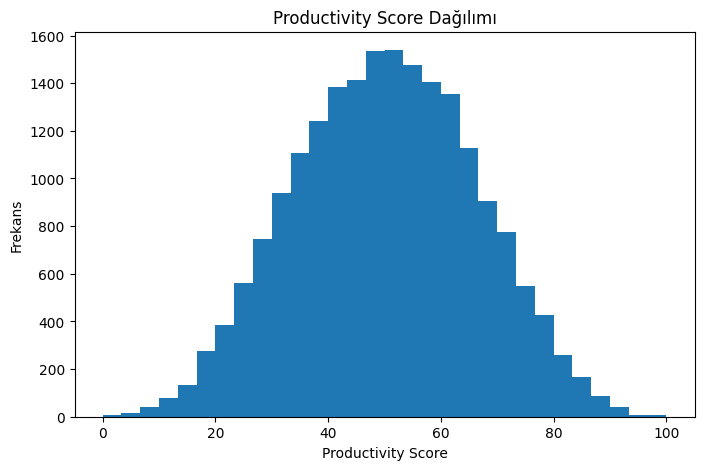

In [37]:
# productivity_score dağılımını histogram ile göster
plt.figure(figsize=(8, 5))
plt.hist(df[target_col], bins=30)
plt.title("Productivity Score Dağılımı")
plt.xlabel("Productivity Score")
plt.ylabel("Frekans")
plt.show()

In [38]:
# Her kategorik sütun için değer sayımlarını yazdır
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- gender ---
gender
Female    9640
Male      9582
Other      778
Name: count, dtype: int64


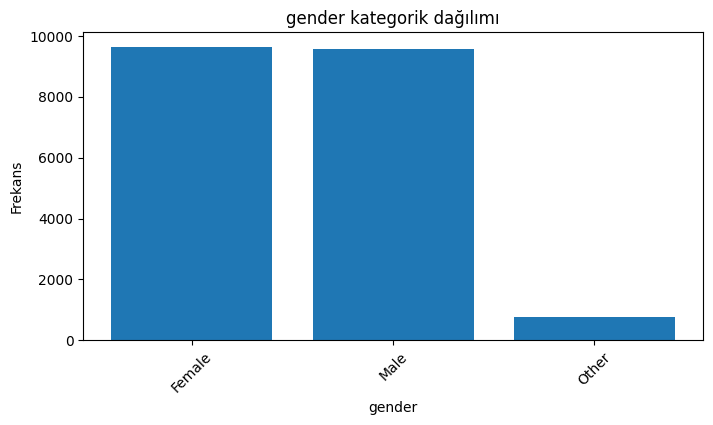

In [39]:
# Kategorik sütunların bar grafiğini çiz
for col in categorical_cols:
    value_counts = df[col].value_counts(dropna=False)

    plt.figure(figsize=(8, 4))
    plt.bar(value_counts.index.astype(str), value_counts.values)
    plt.title(f"{col} kategorik dağılımı")
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.xticks(rotation=45)
    plt.show()

In [17]:
# Sadece sayısal sütunlar arasında korelasyon hesapla
corr_matrix = df[numeric_cols].corr()

# Korelasyon matrisini tablo olarak göster
print("Korelasyon Matrisi:")
display(corr_matrix)

Korelasyon Matrisi:


,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
student_id,1.000000,-0.004398,0.010596,-0.012768,-0.001470,0.000120,-0.004159,0.005024,0.003951,0.004558,-0.002843,0.003091,0.021324,0.006859,0.015330,0.007043,0.012579
age,-0.004398,1.000000,-0.005029,0.010650,0.009090,0.003258,0.013934,0.001777,-0.006727,0.006629,0.001646,-0.003458,-0.006531,-0.002612,-0.004130,-0.000857,-0.005423
study_hours_per_day,0.010596,-0.005029,1.000000,0.001670,0.011539,0.004888,-0.002238,-0.002104,-0.010371,0.004788,0.004380,0.005643,-0.008083,0.001781,0.004536,-0.012208,0.732777
sleep_hours,-0.012768,0.010650,0.001670,1.000000,0.000016,-0.005939,0.004920,-0.003666,-0.000677,0.000882,0.006526,0.000944,0.003433,0.000020,-0.003241,0.010543,0.340902
phone_usage_hours,-0.001470,0.009090,0.011539,0.000016,1.000000,0.004030,0.004108,-0.007497,-0.005431,-0.000064,-0.003186,0.006213,-0.002986,0.006138,-0.000206,-0.012136,-0.326650
social_media_hours,0.000120,0.003258,0.004888,-0.005939,0.004030,1.000000,-0.005172,0.006406,-0.004077,-0.003837,-0.006226,0.003418,0.009388,0.000355,-0.001285,-0.000117,0.001285
youtube_hours,-0.004159,0.013934,-0.002238,0.004920,0.004108,-0.005172,1.000000,0.005033,-0.012604,0.006495,0.002128,0.011149,0.005766,0.007351,0.003745,0.001579,-0.000224
gaming_hours,0.005024,0.001777,-0.002104,-0.003666,-0.007497,0.006406,0.005033,1.000000,0.005545,-0.010977,-0.000823,0.000179,0.010962,0.001791,-0.001462,0.002544,0.000685
breaks_per_day,0.003951,-0.006727,-0.010371,-0.000677,-0.005431,-0.004077,-0.012604,0.005545,1.000000,-0.000057,-0.015312,0.010554,0.003253,0.002395,0.000269,-0.003690,-0.005836
coffee_intake_mg,0.004558,0.006629,0.004788,0.000882,-0.000064,-0.003837,0.006495,-0.010977,-0.000057,1.000000,0.011384,0.007968,0.003035,-0.008850,0.010121,0.015326,0.010190


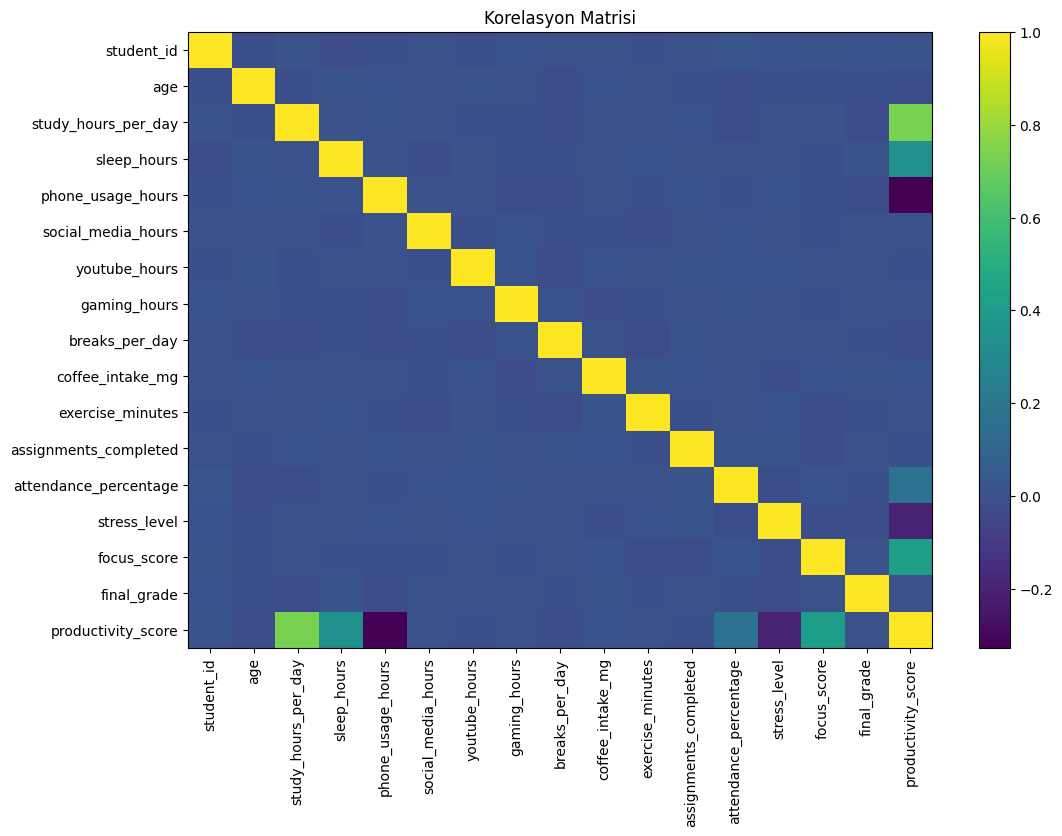

In [40]:
# Korelasyon matrisini renkli olarak göster
plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Korelasyon Matrisi")
plt.show()

In [41]:
# Hedef değişken ile olan korelasyonları sırala
target_corr = corr_matrix[target_col].sort_values(ascending=False)

print("Productivity Score ile korelasyonlar:")
print(target_corr)

Productivity Score ile korelasyonlar:
productivity_score       1.000000
study_hours_per_day      0.732777
focus_score              0.411366
sleep_hours              0.340902
attendance_percentage    0.176107
student_id               0.012579
coffee_intake_mg         0.010190
exercise_minutes         0.002892
final_grade              0.001954
social_media_hours       0.001285
gaming_hours             0.000685
youtube_hours           -0.000224
assignments_completed   -0.001757
age                     -0.005423
breaks_per_day          -0.005836
stress_level            -0.197128
phone_usage_hours       -0.326650
Name: productivity_score, dtype: float64


In [42]:
# Düşürülecek sütunları belirle
drop_cols = [target_col]

# student_id varsa modele sokmuyoruz
# çünkü genelde kimlik sütunu tahmin için anlamlı olmaz
if "student_id" in df.columns:
    drop_cols.append("student_id")

# X = bağımsız değişkenler
X = df.drop(columns=drop_cols)

# y = hedef değişken
y = df[target_col]

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

display(X.head())

X boyutu: (20000, 16)
y boyutu: (20000,)


,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade
0,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87
1,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90
2,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22
3,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77
4,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13


In [43]:
# Veriyi eğitim ve test olarak ayır
# test_size=0.2 -> verinin %20'si test için ayrılır
# random_state sabit olursa hep aynı bölünme olur
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train şekli:", X_train.shape)
print("X_test şekli :", X_test.shape)
print("y_train şekli:", y_train.shape)
print("y_test şekli :", y_test.shape)

X_train şekli: (16000, 16)
X_test şekli : (4000, 16)
y_train şekli: (16000,)
y_test şekli : (4000,)


In [44]:
# Eğitim verisi üzerinden sayısal ve kategorik sütunları belirlemek daha temizdir
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Sayısal özellikler:", numeric_features)
print("Kategorik özellikler:", categorical_features)

Sayısal özellikler: ['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade']
Kategorik özellikler: ['gender']


C:\Users\Ceren\AppData\Local\Temp\ipykernel_22324\2996723322.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [45]:
# Sayısal veriler için:
# 1) Eksik değer varsa medyan ile doldur
# 2) StandardScaler ile ölçekle
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Kategorik veriler için:
# 1) Eksik değer varsa en sık değer ile doldur
# 2) OneHotEncoder ile sayısallaştır
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Hangi sütuna hangi işlem yapılacak onu tanımlıyoruz
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [46]:
# Her model için aynı metrikleri kolayca görmek için fonksiyon yazıyoruz
def regression_report(model, X_train, X_test, y_train, y_test, model_name="Model"):
    # Modeli eğit
    model.fit(X_train, y_train)

    # Eğitim verisi tahmini
    y_train_pred = model.predict(X_train)

    # Test verisi tahmini
    y_test_pred = model.predict(X_test)

    # Eğitim metrikleri
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
    train_r2 = r2_score(y_train, y_train_pred)

    # Test metrikleri
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
    test_r2 = r2_score(y_test, y_test_pred)

    # Sonuçları yazdır
    print(f"\n===== {model_name} =====")
    print("Train MAE  :", train_mae)
    print("Test MAE   :", test_mae)
    print("Train RMSE :", train_rmse)
    print("Test RMSE  :", test_rmse)
    print("Train R2   :", train_r2)
    print("Test R2    :", test_r2)

    # Tahminleri geri döndür
    return y_train_pred, y_test_pred

In [47]:
# Baseline model çok önemlidir
# Hiç özellik kullanmadan sadece ortalamaya yakın tahmin yapar
# Gerçek modeller bundan iyi olmalı
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_train_pred, dummy_test_pred = regression_report(
    dummy_model, X_train, X_test, y_train, y_test, model_name="Dummy Regressor"
)


===== Dummy Regressor =====
Train MAE  : 13.144576997890624
Test MAE   : 13.068870312812502
Train RMSE : 16.09522999394977
Test RMSE  : 16.050527085041974
Train R2   : 0.0
Test R2    : -0.00011075684671313368


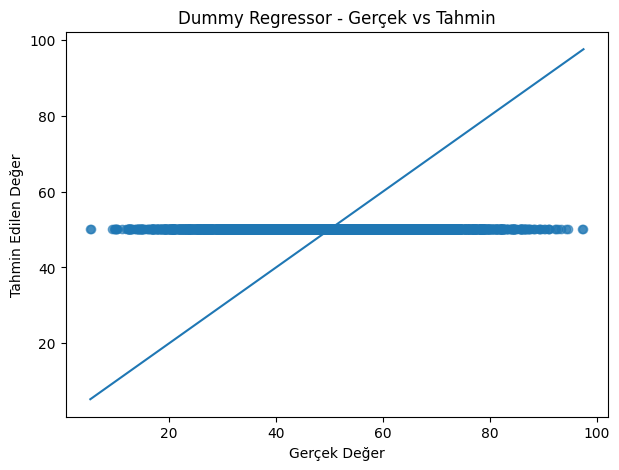

In [48]:
# Dummy model için gerçek ve tahmin edilen değerleri karşılaştıralım

plt.figure(figsize=(7, 5))
plt.scatter(y_test, dummy_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Dummy Regressor - Gerçek vs Tahmin")
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin Edilen Değer")
plt.show()

In [49]:
# En temel regresyon modeli linear
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_train_pred, linear_test_pred = regression_report(
    linear_model, X_train, X_test, y_train, y_test, model_name="Linear Regression"
)


===== Linear Regression =====
Train MAE  : 0.0024870614424505415
Test MAE   : 0.002483414126549558
Train RMSE : 0.0028671377077803205
Test RMSE  : 0.0028725664736039313
Train R2   : 0.9999999682676138
Test R2    : 0.9999999679661103


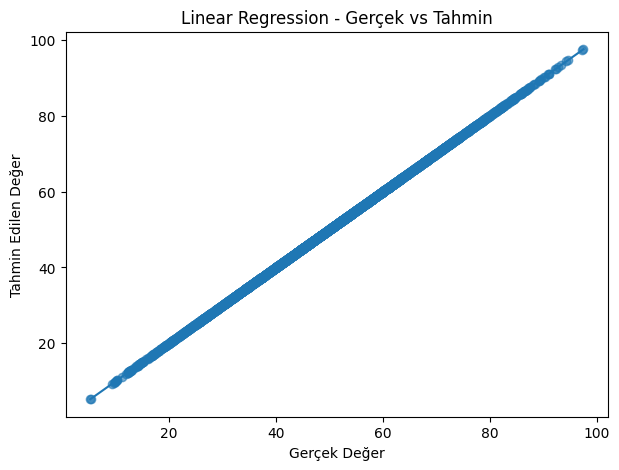

In [50]:
# Linear modelin test tahminleri ne kadar doğru yayılıyor görelim
plt.figure(figsize=(7, 5))
plt.scatter(y_test, linear_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Linear Regression - Gerçek vs Tahmin")
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin Edilen Değer")
plt.show()

In [51]:
# Ridge, lineer regresyonun düzenlileştirilmiş hali
# Özellikle feature sayısı yüksekse yararlı olabilir
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_train_pred, ridge_test_pred = regression_report(
    ridge_model, X_train, X_test, y_train, y_test, model_name="Ridge Regression"
)


===== Ridge Regression =====
Train MAE  : 0.002591155644924276
Test MAE   : 0.0026044910348514807
Train RMSE : 0.0030389947603557134
Test RMSE  : 0.003062537807664423
Train R2   : 0.9999999643495079
Test R2    : 0.9999999635890158


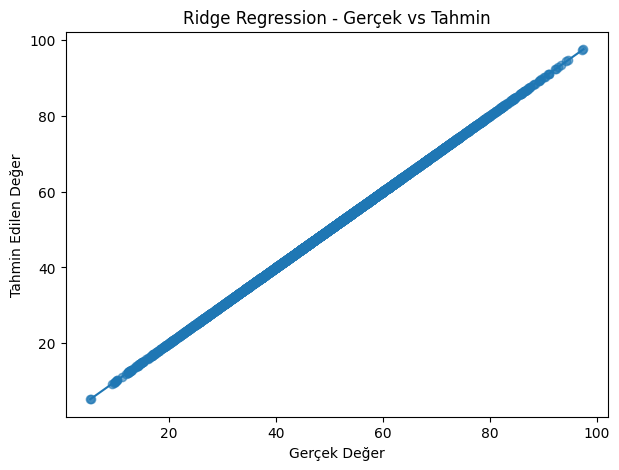

In [52]:
# Ridge modeli için gerçek ve tahmin edilen değerleri karşılaştıralım

plt.figure(figsize=(7, 5))
plt.scatter(y_test, ridge_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Ridge Regression - Gerçek vs Tahmin")
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin Edilen Değer")
plt.show()

In [53]:
# Lasso bazı önemsiz katsayıları sıfıra itebilir
# Böylece feature seçimi gibi de davranabilir
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

lasso_train_pred, lasso_test_pred = regression_report(
    lasso_model, X_train, X_test, y_train, y_test, model_name="Lasso Regression"
)


===== Lasso Regression =====
Train MAE  : 0.019816323529999152
Test MAE   : 0.019988749895709666
Train RMSE : 0.024620644404691066
Test RMSE  : 0.0247346933957731
Train R2   : 0.9999976600614227
Test R2    : 0.9999976248963697


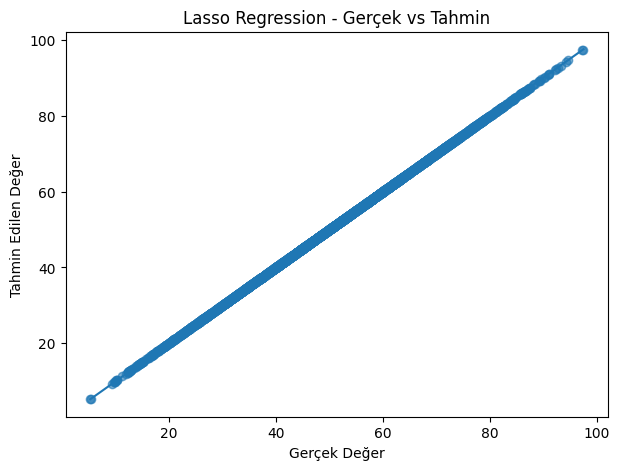

In [54]:
# Lasso modeli için gerçek ve tahmin edilen değerleri karşılaştıralım

plt.figure(figsize=(7, 5))
plt.scatter(y_test, lasso_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Lasso Regression - Gerçek vs Tahmin")
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin Edilen Değer")
plt.show()

In [55]:
# Random Forest doğrusal olmayan ilişkileri de yakalayabilir
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_train_pred, rf_test_pred = regression_report(
    rf_model, X_train, X_test, y_train, y_test, model_name="Random Forest Regressor"
)


===== Random Forest Regressor =====
Train MAE  : 0.7411025812499993
Test MAE   : 1.9768667874999986
Train RMSE : 0.9374090600109564
Test RMSE  : 2.5144543690994112
Train R2   : 0.9966079369244705
Test R2    : 0.9754553401312203


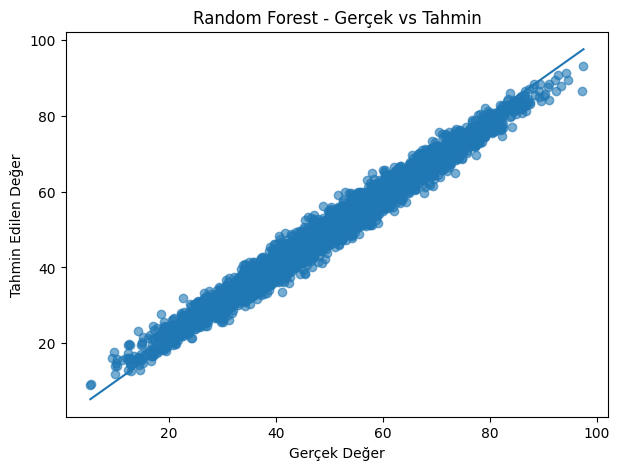

In [56]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Random Forest - Gerçek vs Tahmin")
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin Edilen Değer")
plt.show()

In [67]:
# XGBoost Regressor:
# Tabular veri için güçlü bir boosting modelidir.
# Doğrusal olmayan ilişkileri iyi yakalayabilir.

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),   # Sayısal + kategorik ön işleme
    ("model", XGBRegressor(
        n_estimators=300,             # Ağaç sayısı
        max_depth=6,                  # Ağaç derinliği
        learning_rate=0.05,           # Öğrenme oranı
        subsample=0.8,                # Her ağaçta verinin bir kısmını kullan
        colsample_bytree=0.8,         # Her ağaçta feature'ların bir kısmını kullan
        objective="reg:squarederror", # Regresyon problemi olduğu için bunu kullanıyoruz
        random_state=42
    ))
])

# XGBoost modelini değerlendir
xgb_train_pred, xgb_test_pred = regression_report(
    xgb_model,
    X_train, X_test,
    y_train, y_test,
    model_name="XGBoost Regressor"
)


===== XGBoost Regressor =====
Train MAE  : 0.43581923309579484
Test MAE   : 0.6836582849121093
Train RMSE : 0.5581657282580217
Test RMSE  : 0.8638313452065888
Train R2   : 0.9987973702025623
Test R2    : 0.997103140589805


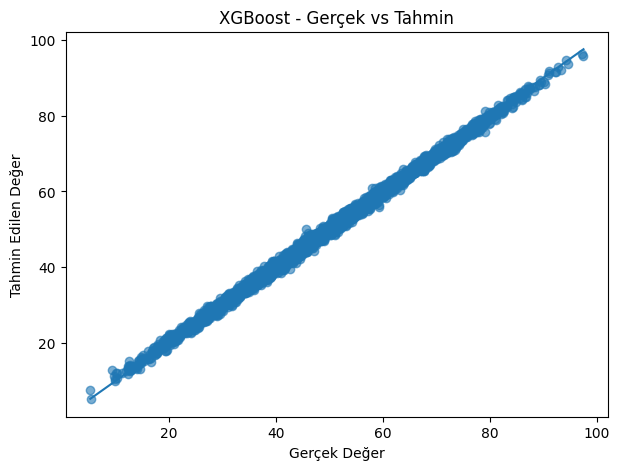

In [58]:
# XGBoost modelinin test verisindeki tahminlerini gerçek değerlerle karşılaştırıyoruz

plt.figure(figsize=(7, 5))
plt.scatter(y_test, xgb_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("XGBoost - Gerçek vs Tahmin")
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin Edilen Değer")
plt.show()

In [59]:
# 5 katlı cross-validation ile modelleri karşılaştırıyoruz
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Tüm modelleri sözlükte topluyoruz
models = {
    "Dummy": dummy_model,
    "Linear": linear_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "RandomForest": rf_model,
    "XGBoost": xgb_model
}

# Sonuçları tutmak için boş liste
cv_results = []

# Her model için CV R2 skorlarını hesapla
for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="r2"
    )

    cv_results.append({
        "Model": name,
        "CV_R2_Ortalama": scores.mean(),
        "CV_R2_Std": scores.std()
    })

# Sonuçları tabloya çevir ve sırala
cv_df = pd.DataFrame(cv_results).sort_values(by="CV_R2_Ortalama", ascending=False)

print("Cross-validation sonuçları:")
display(cv_df)

Cross-validation sonuçları:


,Model,CV_R2_Ortalama,CV_R2_Std
1,Linear,1.000000,3.017080e-10
2,Ridge,1.000000,7.424968e-10
3,Lasso,0.999998,2.898755e-08
5,XGBoost,0.997090,5.414305e-05
4,RandomForest,0.975428,4.850031e-04
0,Dummy,-0.000246,3.202086e-04


In [64]:
# =========================================================
# LINEAR, RIDGE, LASSO İÇİN KATSAYI TABLOLARI
# =========================================================

# Önce modelleri fit edelim
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Preprocessor sonrası oluşan sütun isimlerini al
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

# Katsayıları al
linear_coef = linear_model.named_steps["model"].coef_
ridge_coef = ridge_model.named_steps["model"].coef_
lasso_coef = lasso_model.named_steps["model"].coef_

# DataFrame oluştur
coef_df = pd.DataFrame({
    "Ozellik": feature_names,
    "Linear_Katsayi": linear_coef,
    "Ridge_Katsayi": ridge_coef,
    "Lasso_Katsayi": lasso_coef
})

# Mutlak değer sütunları ekle
coef_df["Linear_Mutlak"] = coef_df["Linear_Katsayi"].abs()
coef_df["Ridge_Mutlak"] = coef_df["Ridge_Katsayi"].abs()
coef_df["Lasso_Mutlak"] = coef_df["Lasso_Katsayi"].abs()

print("Katsayı tablosu:")
display(coef_df.head())

Katsayı tablosu:


,Ozellik,Linear_Katsayi,Ridge_Katsayi,Lasso_Katsayi,Linear_Mutlak,Ridge_Mutlak,Lasso_Mutlak
0,num__age,0.000014,0.000009,-0.000000,0.000014,0.000009,0.000000
1,num__study_hours_per_day,11.843251,11.842507,11.833074,11.843251,11.842507,11.833074
2,num__sleep_hours,5.486395,5.486050,5.476325,5.486395,5.486050,5.476325
3,num__phone_usage_hours,-5.350638,-5.350298,-5.340665,5.350638,5.350298,5.340665
4,num__social_media_hours,-0.000012,-0.000012,-0.000000,0.000012,0.000012,0.000000


In [ ]:

# RANDOM FOREST - FEATURE IMPORTANCE
# Modeli eğit
rf_model.fit(X_train, y_train)

# İç model ve feature isimleri
rf_inner_model = rf_model.named_steps["model"]
rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Importance skorları
rf_importances = rf_inner_model.feature_importances_

# Tablo oluştur
rf_importance_df = pd.DataFrame({
    "Ozellik": rf_feature_names,
    "RF_Onem": rf_importances
}).sort_values(by="RF_Onem", ascending=False)

print("Random Forest importance tablosu:")
display(rf_importance_df.head(15))

Random Forest importance tablosu:


,Ozellik,RF_Onem
1,num__study_hours_per_day,0.539753
13,num__focus_score,0.163844
2,num__sleep_hours,0.113350
3,num__phone_usage_hours,0.108606
12,num__stress_level,0.027691
11,num__attendance_percentage,0.027601
14,num__final_grade,0.002332
8,num__coffee_intake_mg,0.002288
4,num__social_media_hours,0.002285
5,num__youtube_hours,0.002279


In [ ]:

# XGBOOST - FEATURE IMPORTANCE

# Modeli eğit
xgb_model.fit(X_train, y_train)

# İç model ve feature isimleri
xgb_inner_model = xgb_model.named_steps["model"]
xgb_feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Importance skorları
xgb_importances = xgb_inner_model.feature_importances_

# Tablo oluştur
xgb_importance_df = pd.DataFrame({
    "Ozellik": xgb_feature_names,
    "XGB_Onem": xgb_importances
}).sort_values(by="XGB_Onem", ascending=False)

print("XGBoost importance tablosu:")
display(xgb_importance_df.head(15))

XGBoost importance tablosu:


,Ozellik,XGB_Onem
1,num__study_hours_per_day,0.476765
13,num__focus_score,0.180652
2,num__sleep_hours,0.128575
3,num__phone_usage_hours,0.109477
12,num__stress_level,0.062622
11,num__attendance_percentage,0.039101
16,cat__gender_Male,0.000465
17,cat__gender_Other,0.000341
14,num__final_grade,0.000287
10,num__assignments_completed,0.000286


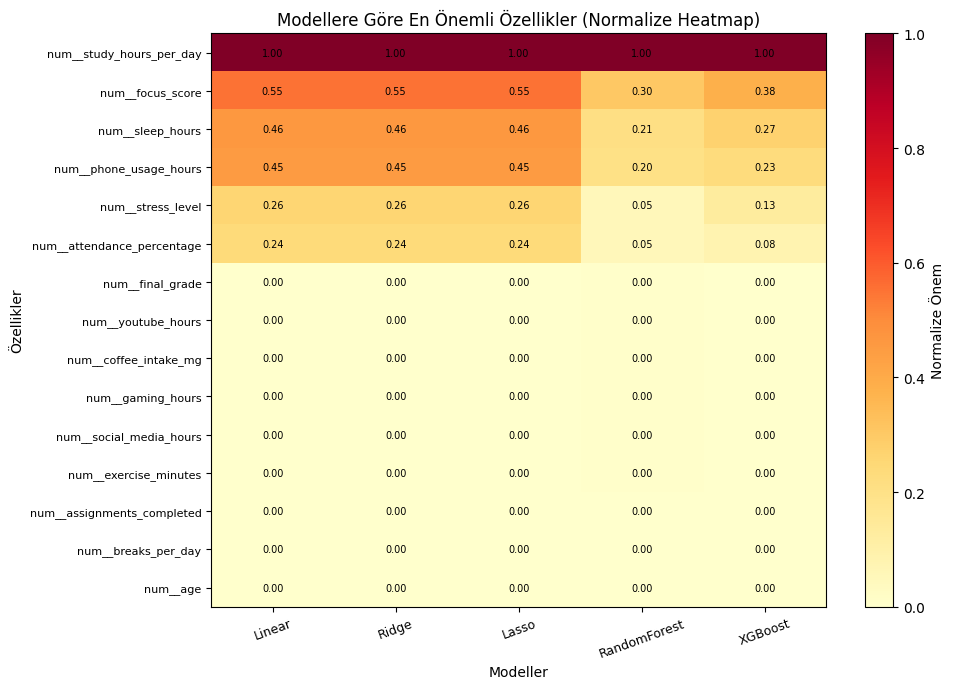

In [ ]:

# TÜM MODELLER İÇİN TOPLU FEATURE IMPORTANCE HEATMAP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1) MODELLERİ EĞİT

linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)


# 2) PREPROCESSING SONRASI FEATURE İSİMLERİNİ AL

feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()


# 3) HER MODEL İÇİN ÖNEM / KATSAYI DEĞERLERİNİ AL

# Doğrusal modellerde yön var (+/-), ama importance için önce büyüklüğe bakıyoruz
linear_importance = np.abs(linear_model.named_steps["model"].coef_)
ridge_importance  = np.abs(ridge_model.named_steps["model"].coef_)
lasso_importance  = np.abs(lasso_model.named_steps["model"].coef_)

# Ağaç tabanlı modellerde importance skorları
rf_importance  = rf_model.named_steps["model"].feature_importances_
xgb_importance = xgb_model.named_steps["model"].feature_importances_

# 4) TEK TABLODA TOPLA

importance_df = pd.DataFrame({
    "Ozellik": feature_names,
    "Linear": linear_importance,
    "Ridge": ridge_importance,
    "Lasso": lasso_importance,
    "RandomForest": rf_importance,
    "XGBoost": xgb_importance
})


# 5) HER MODELİ KENDİ İÇİNDE NORMALİZE ET
#    (0 ile 1 arasına çekiyoruz)

importance_norm = importance_df.copy()

model_cols = ["Linear", "Ridge", "Lasso", "RandomForest", "XGBoost"]

for col in model_cols:
    max_val = importance_norm[col].max()
    
    # Sıfıra bölme hatası olmasın
    if max_val != 0:
        importance_norm[col] = importance_norm[col] / max_val
    else:
        importance_norm[col] = 0


# 6) ORTALAMA ÖNEME GÖRE EN GÜÇLÜ FEATURE'LARI SEÇ

importance_norm["Ortalama_Onem"] = importance_norm[model_cols].mean(axis=1)

# Kaç feature göstermek istiyorsan buradan değiştir
top_n = 15

top_features_df = importance_norm.sort_values(
    by="Ortalama_Onem",
    ascending=False
).head(top_n)

# Heatmap için sadece gerekli sütunları al
heatmap_df = top_features_df[["Ozellik"] + model_cols].set_index("Ozellik")


# 7) HEATMAP ÇİZ

plt.figure(figsize=(10, 7))

# Matris verisini çiz
im = plt.imshow(heatmap_df.values, aspect="auto", cmap="YlOrRd")

# Eksen başlıkları
plt.title("Modellere Göre En Önemli Özellikler (Normalize Heatmap)", fontsize=12)
plt.xlabel("Modeller", fontsize=10)
plt.ylabel("Özellikler", fontsize=10)

# X ve Y ekseni etiketleri
plt.xticks(
    ticks=np.arange(len(heatmap_df.columns)),
    labels=heatmap_df.columns,
    rotation=20,
    fontsize=9
)

plt.yticks(
    ticks=np.arange(len(heatmap_df.index)),
    labels=heatmap_df.index,
    fontsize=8
)

# Hücrelerin içine değer yaz
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

# Renk skalası
cbar = plt.colorbar(im)
cbar.set_label("Normalize Önem", fontsize=10)

plt.tight_layout()
plt.show()

In [70]:
# Her model için test metriklerini aynı tabloda toplamak için yardımcı fonksiyon
def get_test_metrics(model, X_train, X_test, y_train, y_test, model_name):
    # Modeli eğit
    model.fit(X_train, y_train)

    # Test tahmini al
    pred = model.predict(X_test)

    # Metrikleri hesapla
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)

    # Sonucu sözlük olarak döndür
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Tüm model sonuçlarını sırayla ekle
results = []
results.append(get_test_metrics(dummy_model, X_train, X_test, y_train, y_test, "Dummy"))
results.append(get_test_metrics(linear_model, X_train, X_test, y_train, y_test, "Linear"))
results.append(get_test_metrics(ridge_model, X_train, X_test, y_train, y_test, "Ridge"))
results.append(get_test_metrics(lasso_model, X_train, X_test, y_train, y_test, "Lasso"))
results.append(get_test_metrics(rf_model, X_train, X_test, y_train, y_test, "RandomForest"))
results.append(get_test_metrics(xgb_model, X_train, X_test, y_train, y_test, "XGBoost"))

# DataFrame'e çevir
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("Test sonuç karşılaştırması:")
display(results_df)

Test sonuç karşılaştırması:


,Model,MAE,RMSE,R2
1,Linear,0.002483,0.002873,1.000000
2,Ridge,0.002604,0.003063,1.000000
3,Lasso,0.019989,0.024735,0.999998
5,XGBoost,0.683658,0.863831,0.997103
4,RandomForest,1.976867,2.514454,0.975455
0,Dummy,13.068870,16.050527,-0.000111


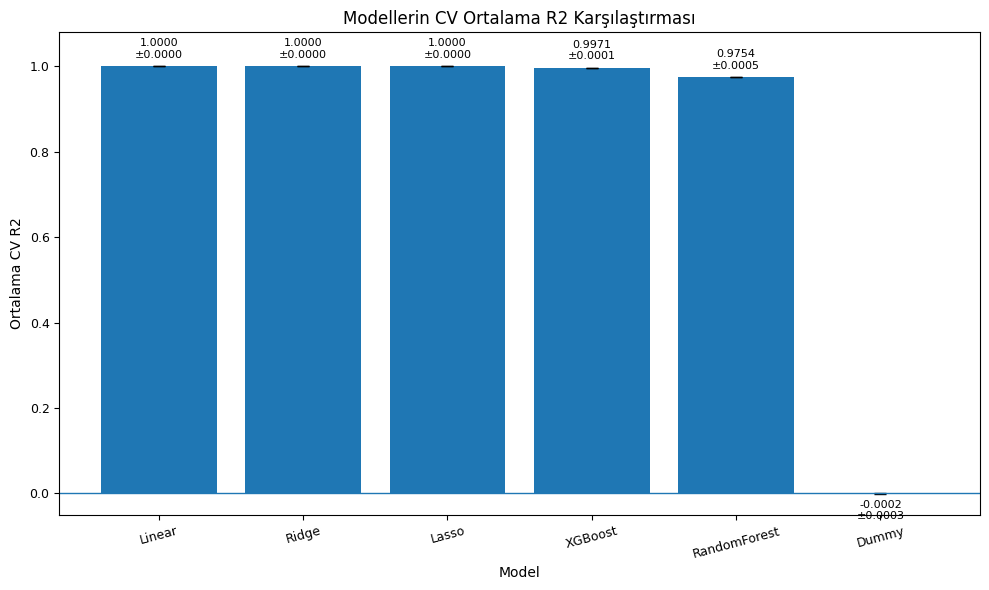

In [71]:
# CV sonuçlarını büyükten küçüğe sırala
cv_df = cv_df.sort_values(by="CV_R2_Ortalama", ascending=False).reset_index(drop=True)

# Grafik boyutu
plt.figure(figsize=(10, 6))

# Bar grafiği + std hata çubukları
bars = plt.bar(
    cv_df["Model"],
    cv_df["CV_R2_Ortalama"],
    yerr=cv_df["CV_R2_Std"],
    capsize=4
)

# Başlık ve eksen isimleri
plt.title("Modellerin CV Ortalama R2 Karşılaştırması", fontsize=12)
plt.xlabel("Model", fontsize=10)
plt.ylabel("Ortalama CV R2", fontsize=10)

# Dummy negatifse görünsün diye alt sınırı negatife çek
min_y = min(cv_df["CV_R2_Ortalama"].min() - 0.05, -0.05)
plt.ylim(min_y, 1.08)

# 0 çizgisi
plt.axhline(y=0, linewidth=1)

# X ekseni yazıları biraz küçülsün ve hafif dönsün
plt.xticks(rotation=15, fontsize=9)
plt.yticks(fontsize=9)

# Her barın üstüne ortalama ve std yaz
for i, bar in enumerate(bars):
    y_value = bar.get_height()
    x_value = bar.get_x() + bar.get_width() / 2
    std_value = cv_df.loc[i, "CV_R2_Std"]

    label = f"{y_value:.4f}\n±{std_value:.4f}"

    if y_value >= 0:
        plt.text(
            x_value,
            y_value + 0.015,
            label,
            ha="center",
            va="bottom",
            fontsize=8
        )
    else:
        plt.text(
            x_value,
            y_value - 0.015,
            label,
            ha="center",
            va="top",
            fontsize=8
        )

# Kenarları sıkıştır
plt.tight_layout()

# Göster
plt.show()

In [74]:
# Sonuç tablosundaki en iyi modeli bul
best_model_name = results_df.iloc[0]["Model"]

print("En iyi test R2 değerine sahip model:", best_model_name)
print("Dummy en kötü modeldir, bu normaldir")
print("Linear / Ridge / Lasso çok yüksek performans verdi")
print("Bu durum veri setinin güçlü doğrusal ilişki veya sentetik yapı içermesinden kaynaklanıyor olabilir")
print("Random Forest ve XGBoost da güçlü sonuç verdi, ama lineer modeller kadar yüksek çıkmadı")



En iyi test R2 değerine sahip model: Linear
Dummy en kötü modeldir, bu normaldir
Linear / Ridge / Lasso çok yüksek performans verdi
Bu durum veri setinin güçlü doğrusal ilişki veya sentetik yapı içermesinden kaynaklanıyor olabilir
Random Forest ve XGBoost da güçlü sonuç verdi, ama lineer modeller kadar yüksek çıkmadı
